In [ ]:
# 1.Preprocess Text Data Using Padding
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# padding
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

In [ ]:
# 2.Change Sequence Length & Compare Results
max_length = 100

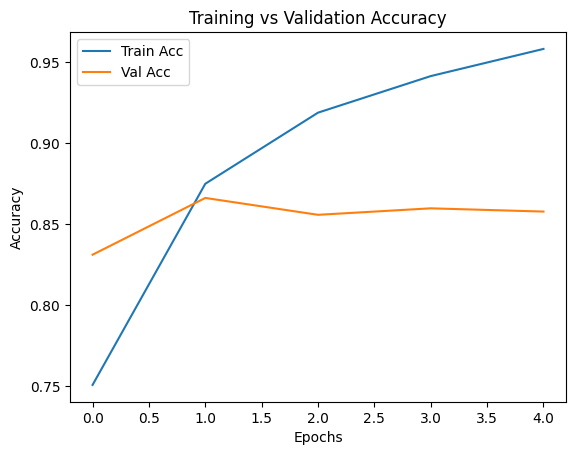

In [ ]:
# 3.Plot Training vs Validation Accuracy
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

In [ ]:
# 4.Identify & Print Misclassified Samples
import numpy as np

y_pred = (model.predict(x_test) > 0.5).astype("int32")

misclassified = np.where(y_pred.flatten() != y_test)[0]

print("Number of misclassified samples:", len(misclassified))

# print few examples
for i in misclassified[:5]:
    print("Index:", i)
    print("Actual:", y_test[i], "Predicted:", y_pred[i][0])
    print("Review (encoded):", x_test[i])
    print("-----")

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step
Number of misclassified samples: 3641
Index: 3
Actual: 0 Predicted: 1
Review (encoded): [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    1   13 1228  119   14  552    7   20  190
   14   58   13  258  546 1786    8 1968    4  268  237   13  191   81
   15   13   80   43 3824   44   12   14   16  427 3192    4  183   15
  593   19    4  351  362   26   55  646   21    4 1239   84   26 1557
 3755   13  244    6 2071  132  184  194    5   13   70 4478  546   73
  190   13   62   24   81  320    4  538    4  117  250  127   11   14
   20   82    4  452   11   14   20    9 8654   19   41  476    8    4
  213    7 9185   13  657   13  286   38 1612   44   41    5   41 1729
   88   13   62   28  900  510    4  509   51    6  612   59   16  193
   61 4666    5  702  930  143  285   25   67   41   81  366    4  130
   82    9  259  334  397 1195    7  149  102   15   26  814   38  465
 1627   31   70  

In [ ]:
# 5.Modify Training to Print Gradient Magnitudes
import tensorflow as tf

optimizer = tf.keras.optimizers.Adam()

loss_fn = tf.keras.losses.BinaryCrossentropy()

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(64)

for epoch in range(3):
    print(f"\nEpoch {epoch+1}")

    for step, (x_batch, y_batch) in enumerate(train_dataset):

        with tf.GradientTape() as tape:
            predictions = model(x_batch, training=True)
            loss = loss_fn(y_batch, predictions)

        grads = tape.gradient(loss, model.trainable_variables)

        # compute gradient magnitude
        grad_norm = tf.linalg.global_norm(grads)
        print(f"Step {step}, Gradient Magnitude: {grad_norm.numpy():.4f}")

        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        if step > 5:   # limit printing
            break


Epoch 1
Step 0, Gradient Magnitude: 0.9439
Step 1, Gradient Magnitude: 2.4738
Step 2, Gradient Magnitude: 1.9145
Step 3, Gradient Magnitude: 6.2908
Step 4, Gradient Magnitude: 0.7989
Step 5, Gradient Magnitude: 2.1100
Step 6, Gradient Magnitude: 1.1210

Epoch 2
Step 0, Gradient Magnitude: 0.6238
Step 1, Gradient Magnitude: 1.7234
Step 2, Gradient Magnitude: 0.9188
Step 3, Gradient Magnitude: 1.4643
Step 4, Gradient Magnitude: 2.6566
Step 5, Gradient Magnitude: 1.0801
Step 6, Gradient Magnitude: 1.7374

Epoch 3
Step 0, Gradient Magnitude: 0.7376
Step 1, Gradient Magnitude: 1.1677
Step 2, Gradient Magnitude: 0.1980
Step 3, Gradient Magnitude: 0.3316
Step 4, Gradient Magnitude: 4.4036
Step 5, Gradient Magnitude: 0.8928
Step 6, Gradient Magnitude: 0.3216
